In [1]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
import time 
from toqito.channels import partial_trace
from scipy.linalg import qr, rq, polar

In [15]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

def Jfun(p):
    return  1/2 * np.arcsin(np.sqrt( 1- 3*p/2 ) )


def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

""" TO DO
check the difference between this function and x=unitary_group.rvs(3)
and the Gaussian unitary ensemble
"""

def random_unitary(n):
    Z = (np.random.randn(n, n) + 1j * np.random.randn(n, n)) / np.sqrt(2)
    Q, R = np.linalg.qr(Z)
    # Fix phases to ensure Haar-uniform sampling
    Q *= np.sign(np.diag(R))

    u, _ = polar(Q)
    return u

def W_rand_sym_tot(p):
    U2 = np.array([[np.exp(-1j * Jfun(p)), 0, 0, 0],
                     [0, 0, -1j * np.exp(1j * Jfun(p)),0],
                     [0, -1j *np.exp(1j * Jfun(p)), 0,0],
                     [0, 0, 0, np.exp(-1j * Jfun(p))]])

    u1 = random_unitary(2)
    u2 = random_unitary(2)

    layer1 = np.kron(u1,u2) 

    u3 = random_unitary(2)
    u4 = random_unitary(2)

    layer2 = np.kron(u3,u4) #v_minus)

    return (layer2 @ U2 @ layer1)


def mkLiouvillian(entP, rate, dt, ldbldOp=S_Z): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    #h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    h = W_rand_sym_tot(entP)

    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[0,2,1,3]),list(U.shape))   
    [eigVals, eigVecs] = linalg.eigh(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVals[i])>1e-10:
            krausOps = krausOps + [ sparse.csr_matrix(np.sqrt(eigVals[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


In [25]:
L1 = np.kron(np.sqrt(rate/2) * S_Z, np.eye(2))
G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
print(G.shape)

(16, 16)


In [26]:
h = W_rand_sym_tot(0.4)

H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
print(H.shape)

(16, 16)


In [27]:
linalg.expm( (-1j*H + G) * dt)


array([[ 4.28202654e+02-3.70388048e-14j,  2.22944314e+02-3.81073645e+02j,
         4.37164405e+02+2.57351128e+02j, -1.89960750e+02-2.16592990e+02j,
         2.22944314e+02+3.81073645e+02j,  4.55208038e+02+2.74151229e-13j,
        -1.41618514e+00+5.23039271e+02j,  9.38509157e+01-2.81822660e+02j,
         4.37164405e+02-2.57351128e+02j, -1.41618514e+00-5.23039271e+02j,
         6.00982544e+02-1.54392966e-14j, -3.24109455e+02-1.06959011e+02j,
        -1.89960750e+02+2.16592990e+02j,  9.38509157e+01+2.81822660e+02j,
        -3.24109455e+02+1.06959011e+02j,  1.93827873e+02-5.57605555e-14j],
       [-3.93701446e+02+5.27076114e+02j,  8.80036927e+02+1.04220213e+02j,
        -5.10143081e+02+1.73599187e+02j,  3.46852923e+02-2.81012551e+01j,
        -6.74046067e+02-7.59468025e+01j,  3.65442977e+02+8.37440358e+02j,
        -4.20099158e+02-3.63610852e+02j,  2.05597826e+02+2.94046503e+02j,
        -8.51667434e+01+7.74722959e+02j,  9.61091683e+02-4.22503520e+02j,
        -4.16486092e+02+4.83829983e+0

In [19]:
def mkGlobalKrausOps(layer, Nqubit, entP, rate, dt, ldbldOp, debug=False):

    allKs = {}

    if np.mod(layer,2) == 0:
        # position records the site with the non-trivial unitary

        positions = [i for i in range(0, Nqubit-1, 2)]

        for pos in positions:

            # one needs to make N/2 different random unitaries
            krausOps = mkKrausOps(mkLiouvillian(entP, rate, dt, ldbldOp))
            allKs[pos] = []

            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))

        for pos in positions:
            krausOps = mkKrausOps(mkLiouvillian(entP, rate, dt, ldbldOp))
            allKs[pos] = []

            if pos < Nqubit-1:

                for i in range(len(krausOps)):
                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]

            else:
                # decomposition of Kraus is required with PBC

                k_abs = decompKrausOps(krausOps)

                for row in k_abs:

                    K_jk = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128')
                        U_chain[pos] = paulis[basisInd//4]
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)]

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]

    return allKs

In [4]:
# employ the faster Kraus Unitary sum
def evolveKrausU(allKs, rho, debug = False):
    
    Nqubit = int(np.log2(len(rho.toarray())))
 
    newRho = rho
    for key in allKs.keys():
        rho = newRho
        newRho = sparse.csr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            newRho += mat @ rho @ mat.T.conj()   
            
            #if debug == True:
            #    print(np.trace(newRho.toarray()))
        
    return newRho


# make measurement  (something is wrong with this thing)
"""TO DO
what on earth is that error???? or in the entanglement entropy computation
"""
def mkS_zMsm(probMsm, rho , debug=False):
    
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.uniform(0,1,Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if list(msmSites) !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2, 
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)
        #print(msmSites)
        
        # make one projection msm at a time:
        for (j,ms) in enumerate(msmSites):  
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            proj0p = reduce(sparse.kron, proj_chain)
            
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            # probability of having one of the outcomes
            prob = np.trace((proj0p @ rho @ proj0p.T.conj()).toarray())
            if np.random.random(1) < prob:
                testRho = (proj0p @ rho @ proj0p.T.conj())/prob
                
            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/(1-prob)

            ## check if the other prob is complementary
            #prob1 = np.trace((proj1p@rho@proj1p.T.conj()).toarray())
            #print(prob+prob1)
            if debug: 
                print(np.trace(testRho.toarray()))
                print(proj_chain)
                
            # One needs to keep track of the measurement!!!
            rho = testRho

    else:
        testRho = rho

    return testRho 


In [5]:
def calcS(densityM, partiesToTraceOut=[1]):
    Ntot=int(np.log2(densityM.shape[0]))
    redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [8]:
import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep',style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [68]:
"""wrong code included - mkGlobalKrausOps


# Step size comparison dt = 0.01, 0.1, 1

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 4

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 30
probMsm = 0
rate = 0
stepSize = [0.1, 0.5, 1, 5, 10]

rep = 20
ensembleS={}
    
#ensembleP = np.zeros([rep,steps])
for dt in stepSize:
    rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

    steps = int(t_total/dt)
    ensembleS[dt] = np.zeros([rep,steps])
    
    startTime = time.time()
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        SList=np.zeros(steps)

        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt)
            rho = evolveKrausU(allKrausOps, rho, debug = False)
            #rho = mkS_zMsm(probMsm, rho)
            
            SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))

            ensembleS[dt][e,s] = SList[s]

    print(time.time()-startTime)
"""
print()

In [ ]:
plt.figure()
for dt in stepSize:
    duration = np.linspace(0,t_total,int(t_total/dt))
    plt.plot(duration, np.average(ensembleS[dt],axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=4')
plt.title('p=0, ensemble size=20')
plt.legend(stepSize)

In [28]:
Nqubit = 6
# check saturation time
t_total = 15
probMsm = 0
rate = 0
dt = 0.05

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

Nqubit = 4

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)

rep = 20 # was 20 before
ensembleS_sat_time={}
    
#ensembleP = np.zeros([rep,steps])
steps = int(t_total/dt)
ensembleS_sat_time = np.zeros([rep,steps])

startTime = time.time()
for e in range(rep):
    rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

    SList=np.zeros(steps)

    for s in range(steps):
        allKrausOps = mkGlobalKrausOps(s, Nqubit, 0.4, rate, dt, S_Z)
        rho = evolveKrausU(allKrausOps, rho, debug = False)
        rho = mkS_zMsm(probMsm, rho)

        SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))

        ensembleS_sat_time[e,s] = SList[s]

print(time.time()-startTime)


24.518506050109863


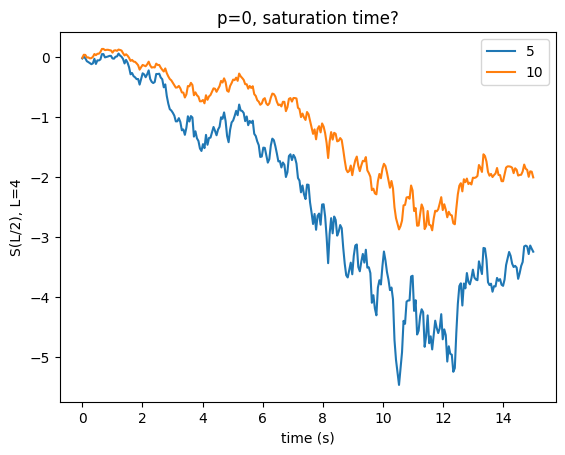

In [29]:
plt.figure()

duration = np.linspace(0,t_total,int(t_total/dt))
plt.plot(duration, np.average(ensembleS_sat_time[:5,:],axis=0) )
plt.plot(duration, np.average(ensembleS_sat_time[:10,:],axis=0) )


plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=4')
plt.title('p=0, saturation time?')
plt.legend([5,10,40])

# The saturation depends on the number of measurement given time


In [10]:
dt

5

In [16]:

# check various system sizes
# pure state start
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
NList = [4, 6, 8]

t_total = 250
probMsm = 0
rate = 0
dt = .1 # outrage?

rep = 10 
ensembleS_N={}
steps = int(t_total/dt)

for Nqubit in NList:

    ensembleS_N[Nqubit] = np.zeros([rep,steps])
    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        SList=np.zeros(steps)

        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, 0.4, rate, dt, S_Z, debug=False)
            rho = evolveKrausU(allKrausOps, rho, debug = False)

            SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))

            ensembleS_N[Nqubit][e,s] = SList[s]
            
    print(time.time()-startTime, flush = True)
    


129.52771306037903


KeyboardInterrupt: 

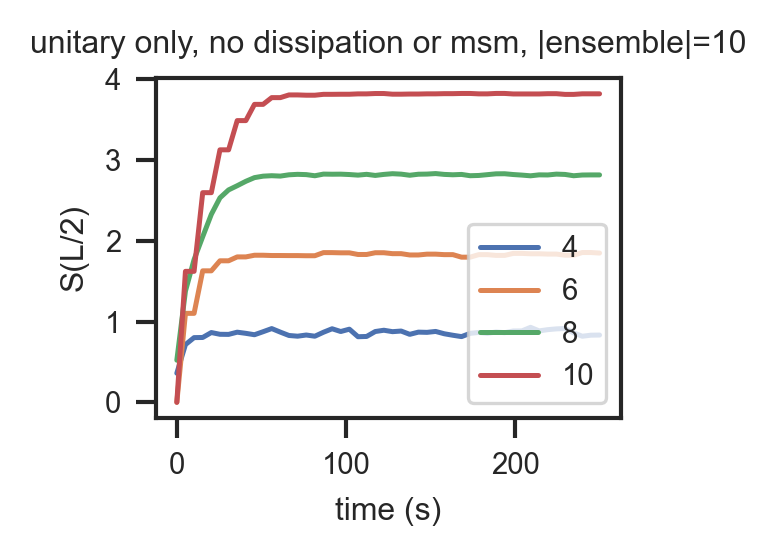

In [69]:
plt.figure()
t_total=250

for (j, Nqubit) in enumerate(NList):
    duration = np.linspace(0,t_total,int(t_total/dt))
    plt.plot(duration, np.average(ensembleS_N[Nqubit] ,axis=0) )
    
plt.xlabel('time (s)')
plt.ylabel('S(L/2)')
plt.title('unitary only, no dissipation or msm, |ensemble|=10')
plt.legend(NList)



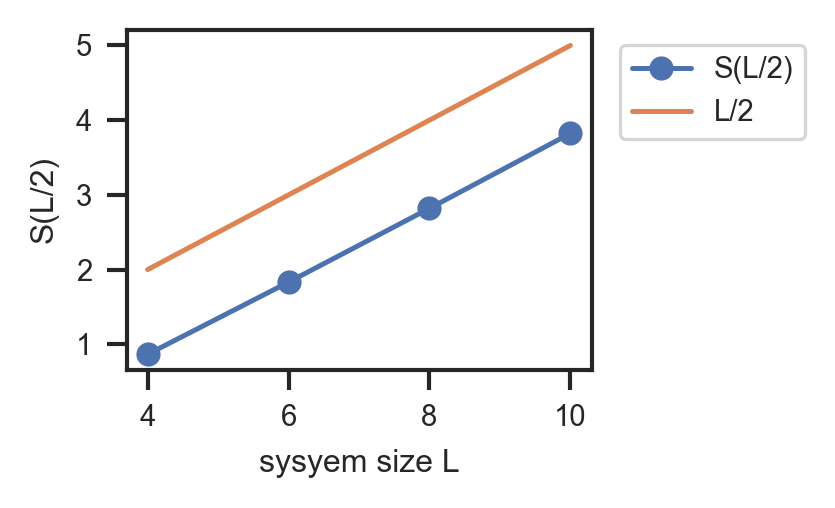

In [19]:
# S scaling with N - volume law limit
avgS_N = [np.average(np.average(ensembleS_N[N] ,axis=0)[30:]) for N in NList]

plt.figure()
plt.plot(np.array(NList).astype(float), np.array(avgS_N).astype(float),'o-')
plt.plot(np.array(NList).astype(float),np.array(NList).astype(float)/2)
plt.xlabel('sysyem size L')
plt.ylabel('S(L/2)')
plt.legend(['S(L/2)','L/2'],bbox_to_anchor= (1.03, 1) )


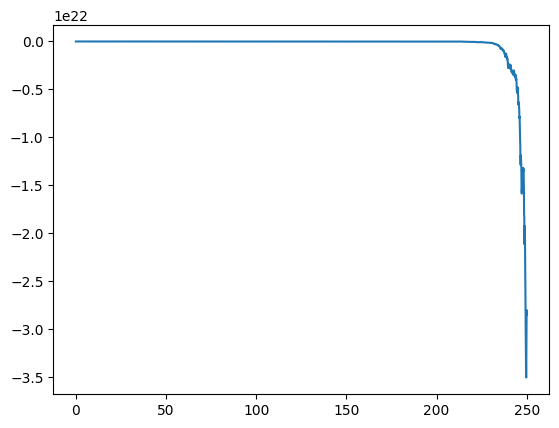

In [18]:
duration = np.linspace(0,t_total,int(t_total/dt))
plt.plot(duration, np.average(ensembleS_N[4] ,axis=0) )
    

In [28]:
# msm rate = 0.3

# check various system sizes
NList = [4, 6, 8, 10]

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 300
probMsm = 0.3
rate = 0
dt = 5 # outrage?

rep = 20 
ensembleS_N_p03={}
    
#ensembleP = np.zeros([rep,steps])
steps = int(t_total/dt)

for Nqubit in NList:

    ensembleS_N_p03[Nqubit] = np.zeros([rep,steps])
    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        SList=np.zeros(steps)

        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt)
            rho = evolveKrausU(allKrausOps, rho)
            rho = mkS_zMsm(probMsm, rho, debug= False)

            SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))

            ensembleS_N_p03[Nqubit][e,s] = SList[s]

    print(time.time()-startTime)


41.623708963394165
97.70534563064575
182.45529699325562
3659.900657892227


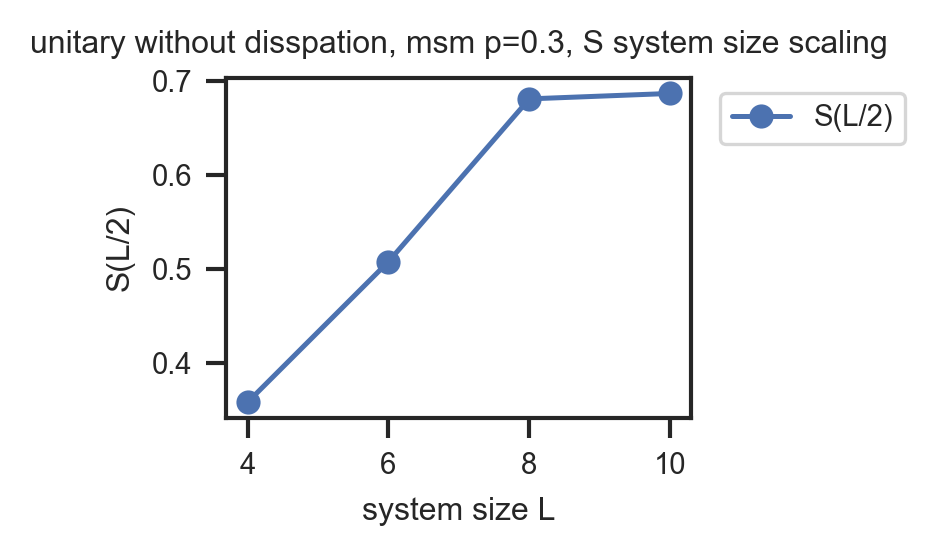

In [65]:
# S scaling with N - area law limit?
"""
plt.figure()

t_total = 300
for (j, Nqubit) in enumerate(NList):
    duration = np.linspace(0,t_total,int(t_total/dt))
    plt.plot(duration, np.average(ensembleS_N_p03[Nqubit] ,axis=0) )
    
plt.xlabel('time (s)')
plt.ylabel('S(L/2)')
plt.title('unitary without disspation, msm p=0.3, |ensemble|=20')
plt.legend(NList)

"""

avgS_N = [np.average(np.average(ensembleS_N_p03[N] ,axis=0)[30:]) for N in NList]

plt.figure()
plt.plot(np.array(NList).astype(float), np.array(avgS_N).astype(float),'o-')
#plt.plot(np.array(NList).astype(float),np.array(NList).astype(float)/2)
plt.xlabel('system size L')
plt.ylabel('S(L/2)')
plt.title('unitary without disspation, msm p=0.3, S system size scaling')
plt.legend(['S(L/2)','L/2'],bbox_to_anchor= (1.03, 1) )


In [54]:
# Now check msm probabilities

# pure state start
state0 = (qb[0] + qb[1])/np.sqrt(2)
state0rho = np.outer(state0, state0)
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

t_total = 300
rate = 0
dt=5
steps = int(t_total/dt)

Nqubit=8


rep = 20
ensembleS={}
ensembleP = {}


probList = [0.01, 0.05, 0.1, 0.15, 0.2, .3, .4, .5, .8, 1]

for probMsm in probList:
    
    ensembleS[probMsm] = np.zeros([rep,steps])
    
    startTime = time.time()
    
    for e in range(rep):
        rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

        SList = np.zeros(steps)

        for s in range(steps):
            allKrausOps = mkGlobalKrausOps(s, Nqubit, rate, dt)
            rho = evolveKrausU(allKrausOps, rho, debug = False)
            rho = mkS_zMsm(probMsm, rho)

            SList[s] = calcS(rho.toarray(), partiesToTraceOut=list(range(1,Nqubit//2)))
            
            ensembleS[probMsm][e,s] = SList[s]

    print(time.time()-startTime)



/Users/cathy/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:43: ComplexWarning: Casting complex values to real discards the imaginary part


84.49084782600403
102.94540405273438
99.38093185424805
113.55997920036316
106.37910103797913
110.84663605690002
120.37309622764587
127.47620415687561
146.9883258342743
158.56172800064087


In [79]:
rho = sparse.csr_matrix(reduce(sparse.kron, [state0rho]*Nqubit))

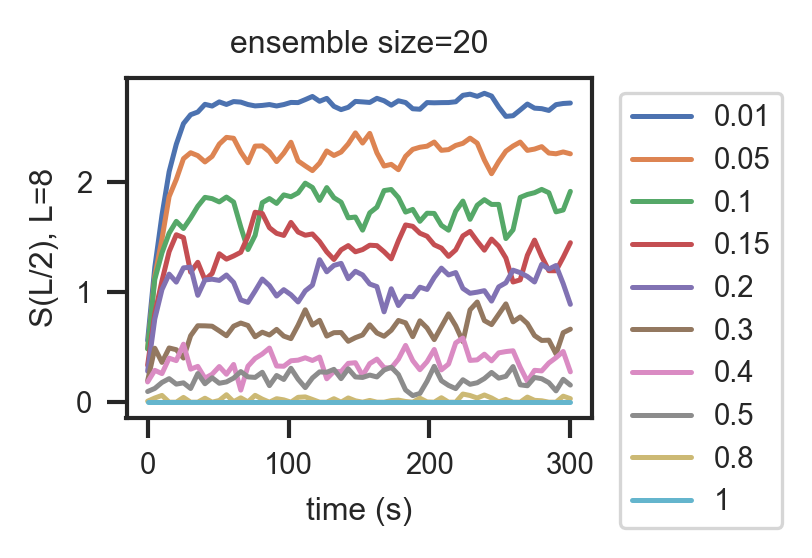

In [55]:
plt.figure()
for (j,probMsm) in enumerate(probList):
    duration = np.linspace(0,t_total,int(t_total/dt))
    plt.plot(duration, np.average(ensembleS[probMsm] ,axis=0) )
plt.xlabel('time (s)')
plt.ylabel('S(L/2), L=8')
plt.title('ensemble size=20')
plt.legend(probList,bbox_to_anchor= (1.03, 1) )


Text(0, 0.5, 'S(L/2),L=8')

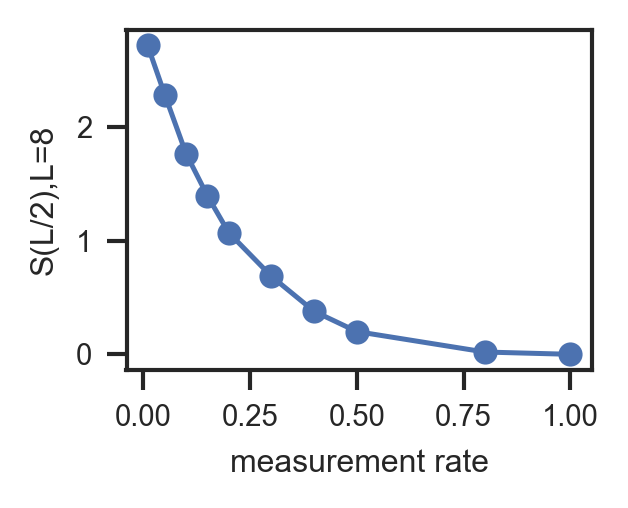

In [56]:
# entanglement entropy vs msm rate
avgS_msmRate = [np.average(np.average(ensembleS[probMsm] ,axis=0)[30:]) for probMsm in probList]

plt.figure()
plt.plot(np.array(probList).astype(float), np.array(avgS_msmRate).astype(float).round(5),'o-')
plt.xlabel('measurement rate')
plt.ylabel('S(L/2),L=8')